# Loading Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Mounting Google Drive to Colab
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Verifying location of data
!ls /content/gdrive/MyDrive/DATA-4381/Data

app.py		    package.json	  train_identity.csv
model_features.pkl  package-lock.json	  train_transaction.csv
node_modules	    submission1.csv	  xgb_fraud_model.pkl
nohup.out	    test_identity.csv
oof_xgb_95.csv	    test_transaction.csv


In [ ]:
# Changing current work directory
%cd /content/gdrive/MyDrive/DATA-4381/Data

/content/gdrive/MyDrive/DATA-4381/Data


In [ ]:
# Loading datasets
df_txn = pd.read_csv('train_transaction.csv') # Transactions Dataset
df_id = pd.read_csv('train_identity.csv') # Identity Dataset

In [ ]:
# Merging Transaction and Identity DataFrames
df = pd.merge(df_txn, df_id, on='TransactionID', how='left')

In [ ]:
pd.set_option('display.max_columns', 500)

NameError: name 'pd' is not defined

In [ ]:
# pd.set_option('display.max_rows', 100)

## PCA

In [ ]:
df.shape

(590540, 434)

Now we remove redundant V features with the PCA components from each block.

### V1-V11

In [ ]:
df_block1 = df.loc[:, 'V1':'V11']

In [ ]:
# Optional: Scree Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardize your data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_block1) # Replace 'df' with your DataFrame

# 2. Run PCA keeping all components
pca = PCA()
pca.fit(scaled_data)

# 3. Calculate Explained Variance
exp_var = pca.explained_variance_ratio_
cum_sum_var = np.cumsum(exp_var)

# 4. Create the Scree Plot
plt.figure(figsize=(10, 6))

# Bar chart for individual variance
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center',
        label='Individual Explained Variance')

# Step plot for cumulative variance
plt.step(range(1, len(cum_sum_var) + 1), cum_sum_var, where='mid',
         label='Cumulative Explained Variance')

plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('PCA Scree Plot')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend(loc='best')
plt.grid(True)
plt.show()


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare block
df_block1 = df.loc[:, 'V1':'V11']

# 2. Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_block1)

# 3. Apply PCA
# Set n_components to the number of dimensions you want to keep
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)

# 4. Create a new DataFrame with the principal components
pca_df = pd.DataFrame(
    data=pca_data,
    columns=['PC1', 'PC2'],
    index=df.index
)

# 5. Check how much variance is explained by each component
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print(pca_df.head())


In [ ]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
df.shape

(590540, 95)

# V Features

In [ ]:
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]
v += [96, 98, 99, 104]
v += [107, 108, 111, 115, 117, 120, 121, 123]
v += [124, 127, 129, 130, 136]
v += [138, 139, 142, 147, 156, 162]
v += [165, 160, 166]
v += [178, 176, 173, 182]
v += [187, 203, 205, 207, 215]
v += [169, 171, 175, 180, 185, 188, 198, 210, 209]
v += [218, 223, 224, 226, 228, 229, 235]
v += [240, 258, 257, 253, 252, 260, 261]
v += [264, 266, 267, 274, 277]
v += [220, 221, 234, 238, 250, 271]
v += [294, 284, 285, 286, 291, 297]
v += [303, 305, 307, 309, 310, 320]
v += [281, 283, 289, 296, 301, 314]
v += [332, 325, 335, 338]

In [ ]:
v_cols_to_keep = [f'V{i}' for i in v]

other_cols = [c for c in df.columns if not c.startswith('V')]

subset_df = df[other_cols + v_cols_to_keep]

In [ ]:
subset_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,V1,V3,V4,V6,V8,V11,V13,V14,V17,V20,V23,V26,V27,V30,V36,V37,V40,V41,V44,V47,V48,V54,V56,V59,V62,V65,V67,V68,V70,V76,V78,V80,V82,V86,V88,V89,V91,V96,V98,V99,V104,V107,V108,V111,V115,V117,V120,V121,V123,V124,V127,V129,V130,V136,V138,V139,V142,V147,V156,V162,V165,V160,V166,V178,V176,V173,V182,V187,V203,V205,V207,V215,V169,V171,V175,V180,V185,V188,V198,V210,V209,V218,V223,V224,V226,V228,V229,V235,V240,V258,V257,V253,V252,V260,V261,V264,V266,V267,V274,V277,V220,V221,V234,V238,V250,V271,V294,V284,V285,V286,V291,V297,V303,V305,V307,V309,V310,V320,V281,V283,V289,V296,V301,V314,V332,V325,V335,V338
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,117.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,117.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,

In [ ]:
subset_df.shape

(590540, 223)

# Loading Test Data

In [ ]:
# Loading test datasets
df_test_txn = pd.read_csv('test_transaction.csv') # Transactions Dataset
df_test_id = pd.read_csv('test_identity.csv') # Identity Dataset

In [ ]:
# Merging Test Transaction and Identity DataFrames
X_test = pd.merge(df_test_txn, df_test_id, on='TransactionID', how='left')

# Finish Loading/Formatting

In [ ]:
# TARGET
y_train = subset_df['isFraud']

X_train = subset_df.drop(['isFraud'], axis=1)

In [ ]:
y_train

,isFraud
0,0
1,0
2,0
3,0
4,0
...,...
590535,0
590536,0
590537,0
590538,0


In [ ]:
X_train.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,V1,V3,V4,V6,V8,V11,V13,V14,V17,V20,V23,V26,V27,V30,V36,V37,V40,V41,V44,V47,V48,V54,V56,V59,V62,V65,V67,V68,V70,V76,V78,V80,V82,V86,V88,V89,V91,V96,V98,V99,V104,V107,V108,V111,V115,V117,V120,V121,V123,V124,V127,V129,V130,V136,V138,V139,V142,V147,V156,V162,V165,V160,V166,V178,V176,V173,V182,V187,V203,V205,V207,V215,V169,V171,V175,V180,V185,V188,V198,V210,V209,V218,V223,V224,V226,V228,V229,V235,V240,V258,V257,V253,V252,V260,V261,V264,V266,V267,V274,V277,V220,V221,V234,V238,V250,V271,V294,V284,V285,V286,V291,V297,V303,V305,V307,V309,V310,V320,V281,V283,V289,V296,V301,V314,V332,V325,V335,V338
0,2987000,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,117.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,117.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,2987001,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,2987002,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,F,F,F,F,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,2987003,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112

# Normalize D Columns

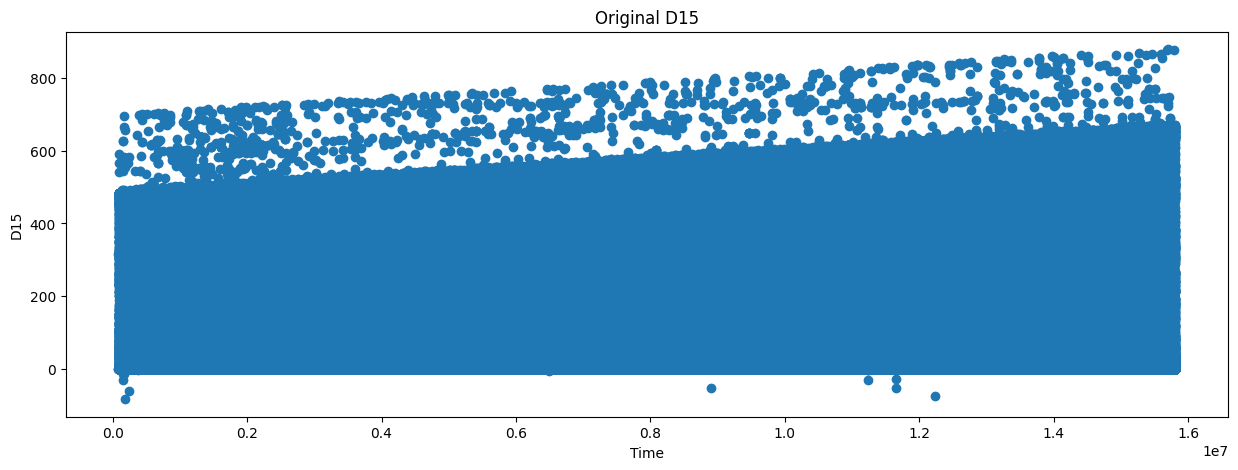

In [ ]:
# PLOT ORIGINAL D
plt.figure(figsize=(15,5))
plt.scatter(subset_df.TransactionDT,subset_df.D15)
plt.title('Original D15')
plt.xlabel('Time')
plt.ylabel('D15')
plt.show()

In [ ]:
# NORMALIZE D COLUMNS
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
    X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60)

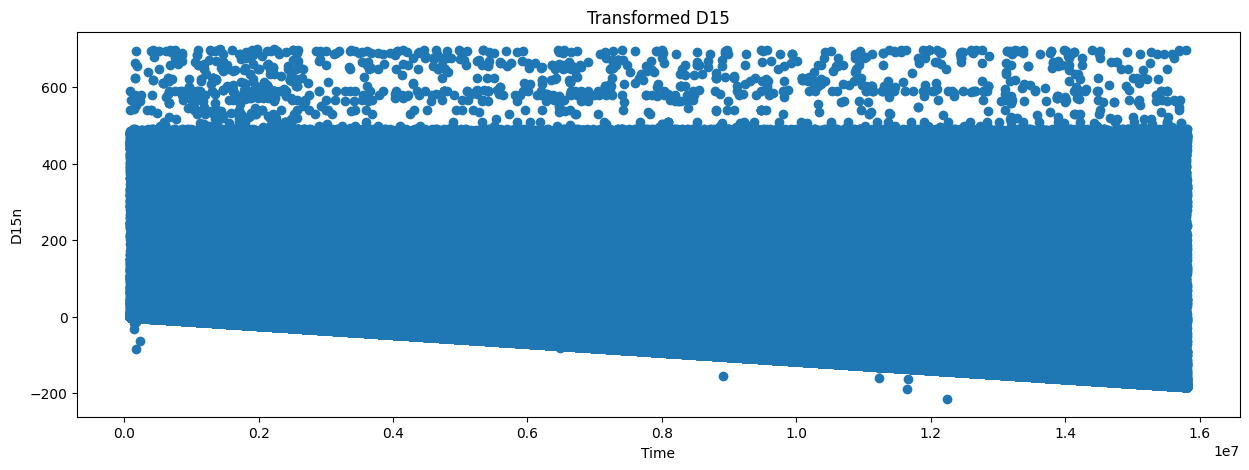

In [ ]:
# PLOT TRANSFORMED D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Transformed D15')
plt.xlabel('Time')
plt.ylabel('D15n')
plt.show()

# Encoding Functions

In [ ]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')

# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000:
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')

# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test,
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')

                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)

                print("'"+new_col_name+"'",', ',end='')

# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str)
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')

# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

# Feature Engineering

In [ ]:
%%time
import gc
# TRANSACTION AMT CENTS
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

cents, addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , card1_addr1 , card1_addr1_P_emaildomain , card1_addr1_FE , card1_addr1_P_emaildomain_FE , 'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 

/tmp/ipykernel_536/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[new_col_name].fillna(-1,inplace=True)
/tmp/ipykernel_536/2377275247.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 

/tmp/ipykernel_536/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[new_col_name].fillna(-1,inplace=True)
/tmp/ipykernel_536/2377275247.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

'TransactionAmt_card1_addr1_P_emaildomain_mean' , 

...

/tmp/ipykernel_536/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[new_col_name].fillna(-1,inplace=True)
/tmp/ipykernel_536/2377275247.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

'D11_card1_addr1_mean' , 'D11_card1_addr1_std' , 

/tmp/ipykernel_536/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[new_col_name].fillna(-1,inplace=True)
/tmp/ipykernel_536/2377275247.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , CPU times: user 5.69 s, sys: 148 ms, total: 5.84 s
Wall time: 5.77 s


/tmp/ipykernel_536/2377275247.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[new_col_name].fillna(-1,inplace=True)
/tmp/ipykernel_536/2377275247.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

# Feature Selection - Time Consistency

In [ ]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)

# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [ ]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 225 FEATURES.


array(['TransactionID', 'TransactionAmt', 'ProductCD', 'card1', 'card2',
       'card3', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2',
       'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6',
       'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2',
       'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M6', 'M7', 'M8', 'M9', 'id_01', 'id_02', 'id_03', 'id_04',
       'id_05', 'id_06', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13',
       'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_28',
       'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType',
       'DeviceInfo', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14',
       'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40',
       'V41', 'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65',
       'V67', 'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88',
       'V89', 'V91', 'V96', 'V98', 'V99', 'V104', 'V107', 'V108', 'V111',
      

# Local Validation

In [ ]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train.index[:3*len(X_train)//4]
idxV = X_train.index[3*len(X_train)//4:]

In [ ]:
# Identify object columns (strings) in your feature list 'cols'
cat_cols = X_train[cols].select_dtypes(include=['object']).columns

# You must convert these in both training and validation sets
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    # Note: If your validation set has the same name, do it there too


In [ ]:
# import xgboost as xgb
# print("XGBoost version:", xgb.__version__)

# clf = xgb.XGBClassifier(
#     n_estimators=2000,
#     max_depth=12,
#     learning_rate=0.02,
#     subsample=0.8,
#     colsample_bytree=0.4,
#     missing=-1,
#     eval_metric='auc',
#     tree_method='hist', # or 'hist' with device='cuda' for XGBoost 2.0+
#     enable_categorical=True
# )

# h = clf.fit(X_train.loc[idxT,cols], y_train[idxT],
#         eval_set=[(X_train.loc[idxV,cols],y_train[idxV])],
#         verbose=50)

XGBoost version: 3.2.0
[0]	validation_0-auc:0.80628
[50]	validation_0-auc:0.90319
[100]	validation_0-auc:0.91703
[150]	validation_0-auc:0.92479
[200]	validation_0-auc:0.92932
[250]	validation_0-auc:0.93217
[300]	validation_0-auc:0.93421
[350]	validation_0-auc:0.93572
[400]	validation_0-auc:0.93633
[450]	validation_0-auc:0.93685
[500]	validation_0-auc:0.93697
[550]	validation_0-auc:0.93679
[600]	validation_0-auc:0.93674


KeyboardInterrupt: 

In [ ]:
# feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
# plt.figure(figsize=(20, 10))
# sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
# plt.title('XGB95 Most Important Features')
# plt.tight_layout()
# plt.show()
# del clf, h; x=gc.collect()

In [ ]:
# early_stopping_rounds moved to constructor
import xgboost as xgb
print("XGBoost version:", xgb.__version__)

clf = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric='auc',
    tree_method='hist', # or 'hist' with device='cuda' for XGBoost 2.0+
    enable_categorical=True,
    early_stopping_rounds=200
)

h = clf.fit(X_train.loc[idxT,cols], y_train[idxT],
        eval_set=[(X_train.loc[idxV,cols],y_train[idxV])],
        verbose=50)

XGBoost version: 3.2.0


KeyError: "None of [Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,\n            9,\n       ...\n       590530, 590531, 590532, 590533, 590534, 590535, 590536, 590537, 590538,\n       590539],\n      dtype='int64', name='TransactionID', length=506885)] are in the [index]"

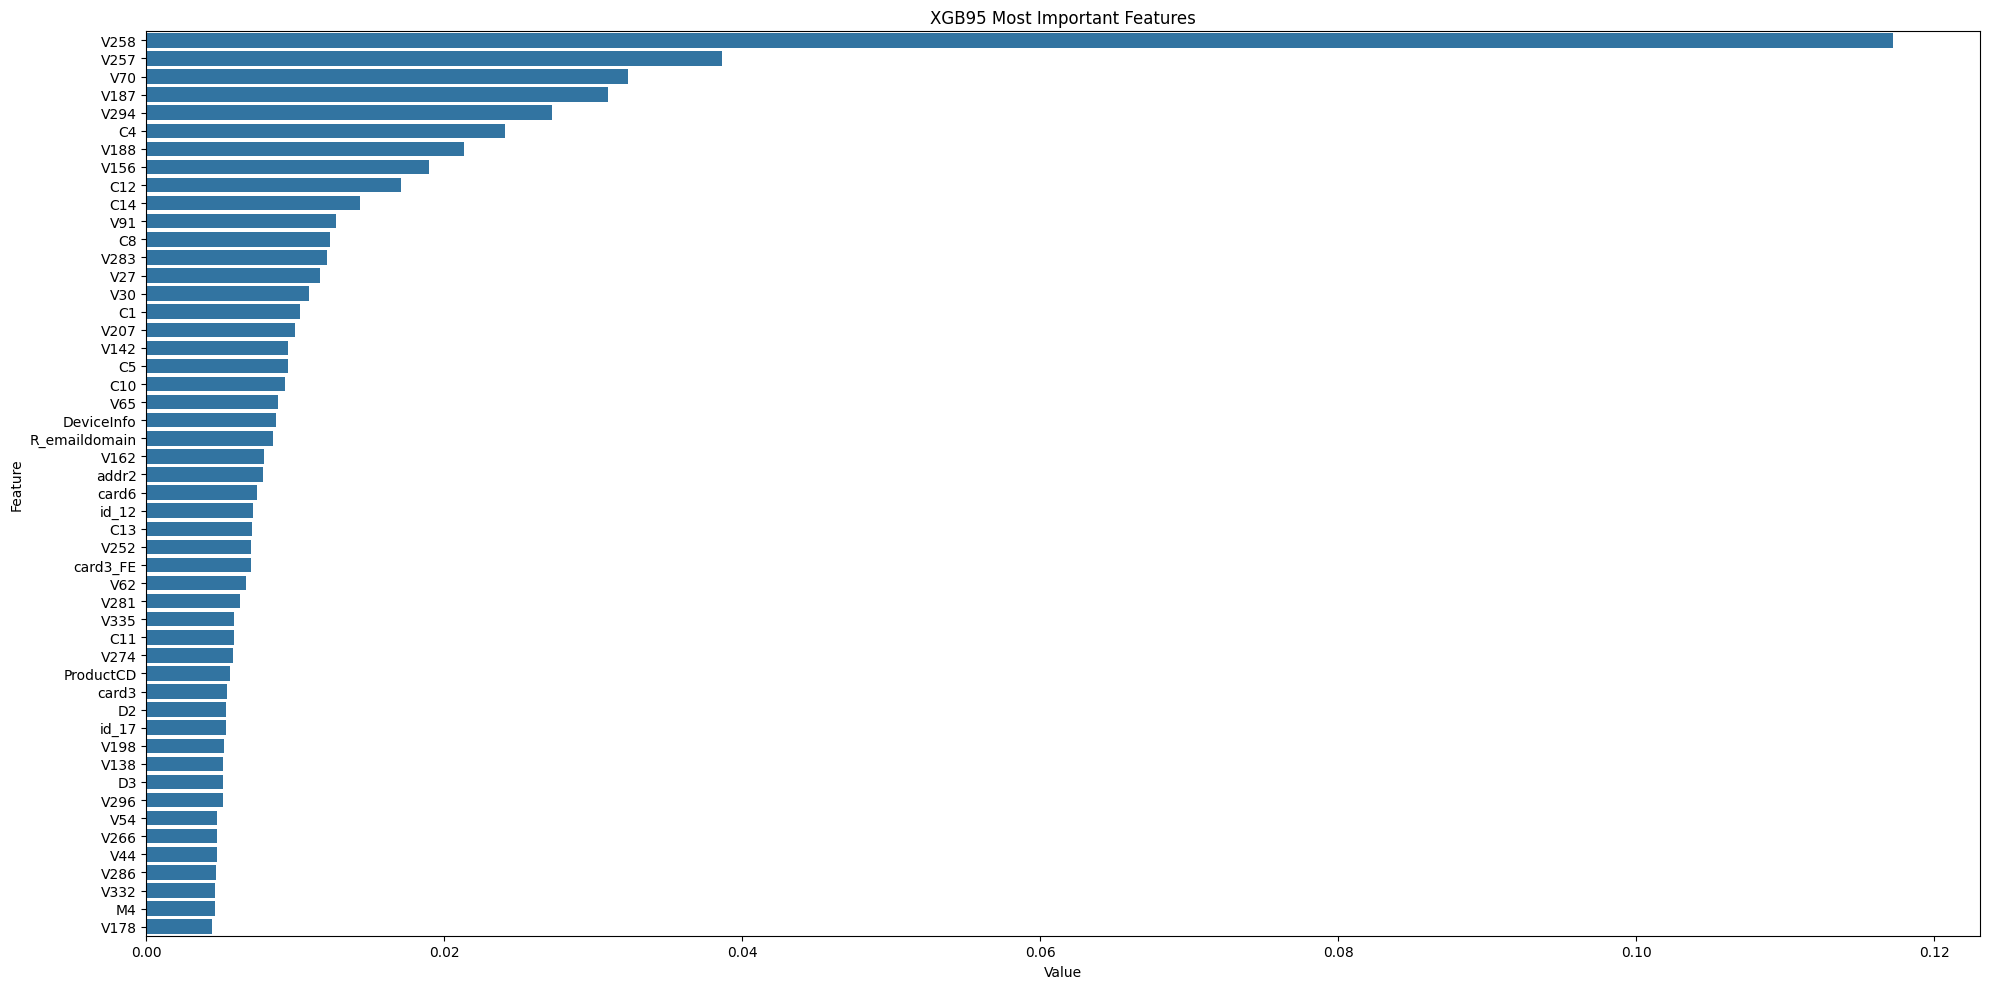

In [ ]:
feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])
plt.figure(figsize=(20, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
plt.title('XGB95 Most Important Features')
plt.tight_layout()
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

# 1. Get predictions for your validation set
y_preds = clf.predict(X_train.loc[idxV, cols])

# 2. Print the report comparing actual (y_train[idxV]) to predicted (y_preds)
print(classification_report(y_train[idxV], y_preds))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    142535
           1       0.86      0.34      0.48      5100

    accuracy                           0.98    147635
   macro avg       0.92      0.67      0.74    147635
weighted avg       0.97      0.98      0.97    147635



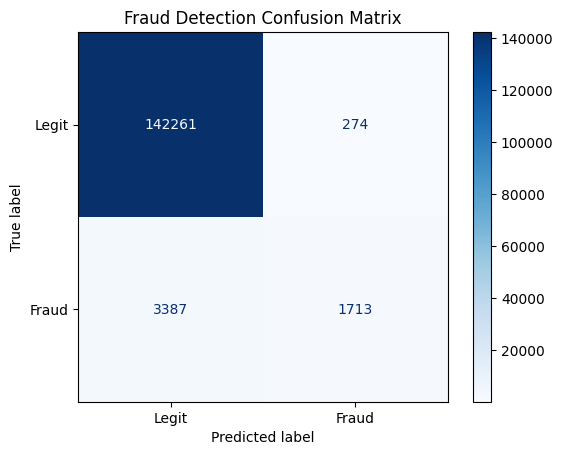

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate the raw matrix
cm = confusion_matrix(y_train[idxV], y_preds)

# 2. Plot it beautifully
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Fraud Detection Confusion Matrix')
plt.show()


# Predict test.csv

In [ ]:
# Fixing - and _ in id columns in Test
X_test.columns = [col.replace('-', '_') if 'id' in col else col for col in X_test.columns]

In [ ]:
# String to Category in Test
# Identify all string/object columns in your feature list
cat_cols = X_test[cols].select_dtypes(include=['object']).columns

# Convert them to 'category' in BOTH Train and Test
for col in cat_cols:
    X_test[col] = X_test[col].astype('category')

print(f"Converted {len(cat_cols)} columns to category dtype.")


Converted 24 columns to category dtype.


In [ ]:
import datetime
START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
X_train['DT_M'] = X_train['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_train['DT_M'] = (X_train['DT_M'].dt.year-2017)*12 + X_train['DT_M'].dt.month

X_test['DT_M'] = X_test['TransactionDT'].apply(lambda x: (START_DATE + datetime.timedelta(seconds = x)))
X_test['DT_M'] = (X_test['DT_M'].dt.year-2017)*12 + X_test['DT_M'].dt.month

In [ ]:
from sklearn.model_selection import GroupKFold
oof = np.zeros(len(X_train))
preds = np.zeros(len(X_test))

skf = GroupKFold(n_splits=6)
for i, (idxT, idxV) in enumerate( skf.split(X_train, y_train, groups=X_train['DT_M']) ):
    month = X_train.iloc[idxV]['DT_M'].iloc[0]
    print('Fold',i,'withholding month',month)
    print(' rows of train =',len(idxT),'rows of holdout =',len(idxV))
    clf = xgb.XGBClassifier(
        n_estimators=5000,
        max_depth=12,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.4,
        missing=-1,
        eval_metric='auc',
        # USE CPU
        #nthread=4,
        #tree_method='hist'
        # USE GPU
        tree_method='hist',
        enable_categorical=True,
        early_stopping_rounds=200
    )
    h = clf.fit(X_train[cols].iloc[idxT], y_train.iloc[idxT],
            eval_set=[(X_train[cols].iloc[idxV],y_train.iloc[idxV])],
            verbose=100)

    oof[idxV] += clf.predict_proba(X_train[cols].iloc[idxV])[:,1]
    preds += clf.predict_proba(X_test[cols])[:,1]/skf.n_splits
    x=gc.collect()
print('#'*20)
print ('XGB95 OOF CV=',roc_auc_score(y_train,oof))

Fold 0 withholding month 12
 rows of train = 453219 rows of holdout = 137321
[0]	validation_0-auc:0.80153
[100]	validation_0-auc:0.88883
[200]	validation_0-auc:0.90084
[300]	validation_0-auc:0.90729
[400]	validation_0-auc:0.91035
[500]	validation_0-auc:0.90999
[598]	validation_0-auc:0.90957
Fold 1 withholding month 15
 rows of train = 488908 rows of holdout = 101632
[0]	validation_0-auc:0.83026
[100]	validation_0-auc:0.92637
[200]	validation_0-auc:0.93764
[300]	validation_0-auc:0.94186
[400]	validation_0-auc:0.94400
[500]	validation_0-auc:0.94502
[600]	validation_0-auc:0.94564
[700]	validation_0-auc:0.94570
[800]	validation_0-auc:0.94574
[900]	validation_0-auc:0.94590
[1000]	validation_0-auc:0.94576
[1100]	validation_0-auc:0.94561
[1168]	validation_0-auc:0.94550
Fold 2 withholding month 13
 rows of train = 497955 rows of holdout = 92585
[0]	validation_0-auc:0.83098
[100]	validation_0-auc:0.92310
[200]	validation_0-auc:0.93590
[300]	validation_0-auc:0.94117
[400]	validation_0-auc:0.9433

NameError: name 'roc_auc_score' is not defined

In [ ]:
from sklearn.metrics import roc_auc_score
print ('XGB95 OOF CV=',roc_auc_score(y_train,oof))

XGB95 OOF CV= 0.9395563278582968


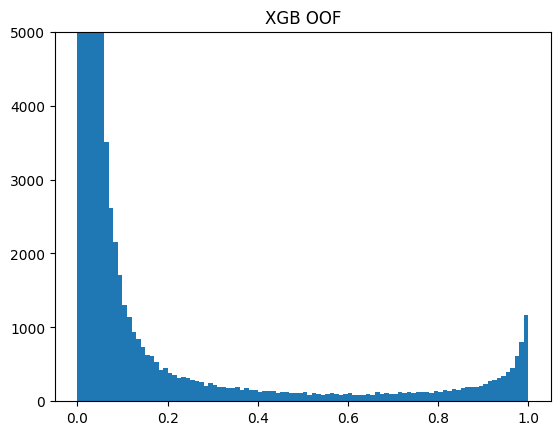

In [ ]:
plt.hist(oof,bins=100)
plt.ylim((0,5000))
plt.title('XGB OOF')
plt.show()

X_train['oof'] = oof
X_train.reset_index(inplace=True)
X_train[['TransactionID','oof']].to_csv('oof_xgb_95.csv')
X_train.set_index('TransactionID',drop=True,inplace=True)

# Kaggle Submission

In [ ]:
# sample_submission = pd.read_csv('../input/ieee-fraud-detection/sample_submission.csv')
# sample_submission.isFraud = preds
# sample_submission.to_csv('sub_xgb_95.csv',index=False)

# plt.hist(sample_submission.isFraud,bins=100)
# plt.ylim((0,5000))
# plt.title('XGB95 Submission')
# plt.show()

In [ ]:
# import pandas as pd

# # 1. Load the original sample submission to get the correct TransactionIDs
# # (Or use X_test['TransactionID'] if you still have it in memory)
# sample_submission = X_test['TransactionID']

# # 2. Assign your averaged predictions to the isFraud column
# sample_submission['isFraud'] = preds

# # 3. Save to a CSV file
# sample_submission.to_csv('submission1.csv', index=False)

# print("Submission file 'submission.csv' is ready!")


/tmp/ipykernel_536/1487521928.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_submission['isFraud'] = preds


Submission file 'submission.csv' is ready!


In [ ]:
import pandas as pd

# 1. Create a NEW DataFrame with the IDs
submission = pd.DataFrame({
    'TransactionID': X_test['TransactionID'],
    'isFraud': preds
})

# 2. Save it
submission.to_csv('submission1.csv', index=False)

print("Submission file is ready!")


Submission file is ready!


In [ ]:
submission

,TransactionID,isFraud
0,3663549,0.000586
1,3663550,0.001920
2,3663551,0.001688
3,3663552,0.001095
4,3663553,0.002283
...,...,...
506686,4170235,0.011343
506687,4170236,0.003413
506688,4170237,0.007795
506689,4170238,0.005042


# Deployment

In [ ]:
import joblib

# Save the model
joblib.dump(clf, 'xgb_fraud_model.pkl')

# Save your feature list (very important!)
joblib.dump(cols, 'model_features.pkl')


['model_features.pkl']

In [ ]:
!pip install -q streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load model and feature list
model = joblib.load('xgb_fraud_model.pkl')
model_cols = joblib.load('model_features.pkl')

st.title("Fraud Detection Predictor")

# 1. Create inputs for Top 10 Features
col1, col2 = st.columns(2)

with col1:
    v258 = st.number_input("V258 (Numeric)", value=0.0)
    v257 = st.number_input("V257 (Numeric)", value=0.0)
    v70  = st.number_input("V70 (Numeric)",  value=0.0)
    v187 = st.number_input("V187 (Numeric)", value=0.0)
    v294 = st.number_input("V294 (Numeric)", value=0.0)

with col2:
    c4   = st.number_input("C4 (Count)",     value=0.0)
    v188 = st.number_input("V188 (Numeric)", value=0.0)
    v156 = st.number_input("V156 (Numeric)", value=0.0)
    c12  = st.number_input("C12 (Count)",    value=0.0)
    c14  = st.number_input("C14 (Count)",    value=0.0)

# Add TransactionAmt
amt = st.number_input("Transaction Amount ($)", value=50.0)

if st.button("Run Fraud Predictor"):
    # Inputs
    input_df = pd.DataFrame(0, index=[0], columns=model_cols)

    input_df['V258'] = v258
    input_df['V257'] = v257
    input_df['V70']  = v70
    input_df['V187'] = v187
    input_df['V294'] = v294
    input_df['C4']   = c4
    input_df['V188'] = v188
    input_df['V156'] = v156
    input_df['C12']  = c12
    input_df['C14']  = c14
    input_df['TransactionAmt'] = amt

    # Handle Categorical Columns
    cat_cols = [c for c in model_cols if input_df[c].dtype == 'object' or c in ['ProductCD', 'card4', 'card6']]
    for col in cat_cols:
        if col in input_df.columns:
            input_df[col] = input_df[col].astype('category')

    # Predict Probability
    prob = model.predict_proba(input_df)[0, 1]

    # Display Result
    st.divider()
    st.metric(label="Fraud Risk Probability", value=f"{prob:.2%}")

    if prob > 0.5:
        st.error("High Risk")
    else:
        st.success("Low Risk")


Overwriting app.py


In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦
up to date, audited 23 packages in 760ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

In [ ]:
!streamlit run /content/app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙your url is: https://silver-icons-boil.loca.lt
^C


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙2026-04-06 21:02:42.580 INFO    numexpr.utils: NumExpr defaulting to 12 threads.
your url is: https://slick-phones-behave.loca.lt
Traceback (most recent call last):
  File "/usr/local/bin/streamlit", line 5, in <module>
    from streamlit.web.cli import main
  File "/usr/local/lib/python3.12/dist-packages/streamlit/__init__.py", line 70, in <module>
    from streamlit.delta_generator import DeltaGenerator as _DeltaGenerator
  File "/usr/local/lib/python3.12/dist-packages/streamlit/delta_generator.py", line 91, in <module>
    from streamlit.elements.arrow_altair import ArrowAltairMixin
  File "/usr/local/lib/python3.12/dist-packages/streamlit/elements/arrow_altair.py", line 35, in <module>
    from altair.vegalite.v4.api import Chart
ModuleNotFoundError: No module named 'altair.vegalite.v4'
^C


In [ ]:
!pip install pyngrok
from pyngrok import ngrok

# 1. Authenticate (Only do this once)
!ngrok config add-authtoken 3C02WRGorETC5TsWr8Na9NOZ1sv_4T9hywB9Q7kBCFi7bMG8V

# 2. Run Streamlit in the background
import os
os.system("streamlit run app.py &")

# 3. Create the tunnel
public_url = ngrok.connect(8501)
print(f"Click here to open your app: {public_url}")


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
Click here to open your app: NgrokTunnel: "https://lucienne-hyperscrupulous-coolingly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
from pyngrok import ngrok
import os

# 1. Kill any existing ngrok or streamlit processes to clear the ports
!pkill streamlit
!pkill ngrok

# 2. Start Streamlit in the background and force it to a specific port
# The 'nohup' and '&' ensure it keeps running without blocking the cell
!nohup streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &

# 3. Wait a few seconds for the server to initialize
import time
time.sleep(5)

# 4. Open the tunnel using the same port (8501) and bind to HTTPS
# bind_tls=True forces a secure connection to avoid browser warnings
public_url = ngrok.connect(8501, bind_tls=True)
print(f"Click this link to open your app: {public_url}")


nohup: appending output to 'nohup.out'
Click this link to open your app: NgrokTunnel: "https://lucienne-hyperscrupulous-coolingly.ngrok-free.dev" -> "http://localhost:8501"


# Streamlit Again

In [ ]:
# 1. Kill any existing ngrok or streamlit processes to clear the ports
!pkill streamlit
!pkill ngrok

# Check XGBoost Model

In [ ]:
# import xgb
import xgboost as xgb

In [ ]:
print(xgb.__version__)

3.2.0
